<a href="https://colab.research.google.com/github/Govind-2004/Exit_exam/blob/main/Exit_exam_DNN_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [88]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import tensorflow as tf
from tensorflow import keras
from keras import layers
import keras_tuner as kt


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#Task 1: DATA Exploration and Understanding

## Load and Inspect dataset

In [3]:
filepath = '/content/drive/MyDrive/Colab Notebooks/Datasets /dataset.csv'
df_asteroid = pd.read_csv(filepath)


/tmp/ipykernel_2812/2974073580.py:2: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asteroid = pd.read_csv(filepath)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [4]:
df_asteroid.head(10)

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


## Identify type of features

In [7]:
# shape of the dataset
df_asteroid.shape

(958524, 45)

In [8]:
# size of the dataset
df_asteroid.size

43133580

In [10]:
df_asteroid.describe()

,spkid,H,diameter,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,rms
count,9.585240e+05,952261.000000,136209.000000,135103.000000,136081.000000,9.585240e+05,958524.000000,9.585240e+05,958524.000000,958524.000000,...,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.386020e+05,9.385980e+05,9.386020e+05,9.386020e+05,9.385980e+05,958522.000000
mean,3.810114e+06,16.906411,5.506429,0.130627,0.479184,2.458869e+06,58868.781950,2.019693e+07,0.156116,2.902143,...,1.982929e+01,1.168449e+00,5.310234e+00,1.370062e+06,1.369977e+06,2.131453e+01,5.060221e-02,4.312780e+08,8.525815e+04,0.561153
std,6.831541e+06,1.790405,9.425164,0.110323,0.782895,7.016716e+02,701.671573,1.930354e+04,0.092643,39.719503,...,2.903785e+03,1.282231e+02,1.333381e+03,9.158996e+08,9.158991e+08,7.197034e+03,9.814953e+00,2.953046e+11,2.767681e+07,2.745700
min,2.000001e+06,-1.100000,0.002500,0.001000,0.000500,2.425052e+06,25051.000000,1.927062e+07,0.000000,-14702.447872,...,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,0.000000
25%,2.239632e+06,16.100000,2.780000,0.053000,0.180000,2.459000e+06,59000.000000,2.020053e+07,0.092193,2.387835,...,1.462000e-07,6.095900e-06,3.619400e-05,5.755000e-05,2.573700e-05,2.340900e-08,2.768800e-09,1.110900e-04,1.794500e-05,0.518040
50%,2.479262e+06,16.900000,3.972000,0.079000,0.332000,2.459000e+06,59000.000000,2.020053e+07,0.145002,2.646969,...,2.271900e-07,8.688800e-06,6.642550e-05,1.047100e-04,4.900100e-05,4.359000e-08,4.638000e-09,2.230800e-04,3.501700e-05,0.566280
75%,3.752518e+06,17.714000,5.765000,0.190000,0.620000,2.459000e+06,59000.000000,2.020053e+07,0.200650,3.001932,...,6.583200e-07,1.591500e-05,1.609775e-04,3.114400e-04,1.718900e-04,1.196600e-07,1.124000e-08,8.139600e-04,9.775475e-05,0.613927
max,5.401723e+07,33.200000,939.400000,1.000000,140.000000,2.459000e+06,59000.000000,2.020053e+07,1.855356,33488.895955,...,1.015000e+06,5.533000e+04,1.199100e+06,8.845100e+11,8.845100e+11,5.509700e+06,7.698800e+03,2.853100e+14,1.910700e+10,2686.600000


In [11]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  object 
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  object 
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   object 
 5   prefix          18 non-null      object 
 6   neo             958520 non-null  object 
 7   pha             938603 non-null  object 
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  object 
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  object 
 17  e         

In [16]:
numerical_cols = df_asteroid.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_asteroid.select_dtypes(include=['object']).columns.tolist()
print(numerical_cols)
print(categorical_cols)

['spkid', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']
['id', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'orbit_id', 'equinox', 'class']


## Check missing and duplicate values

In [12]:
df_asteroid.isnull().sum()

,0
id,0
spkid,0
full_name,0
pdes,0
name,936460
prefix,958506
neo,4
pha,19921
H,6263
diameter,822315


In [14]:
df_asteroid.head(15)

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


In [13]:
df_asteroid.duplicated().sum()

# No duplicate values found

np.int64(0)

## Distribution of diameter and other features

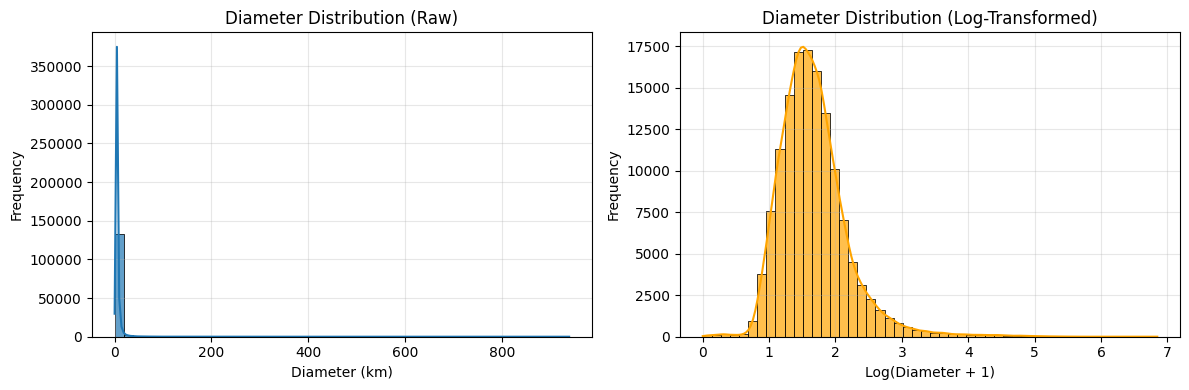

Skewness (raw): 25.85
Skewness (log): 1.54


In [21]:
# Visualize diameter distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_asteroid['diameter'].dropna(),kde = True, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Diameter (km)')
plt.ylabel('Frequency')
plt.title('Diameter Distribution (Raw)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
diameter_log = np.log1p(df_asteroid['diameter'])
sns.histplot(diameter_log.dropna(), bins=50,kde = True, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Log(Diameter + 1)')
plt.ylabel('Frequency')
plt.title('Diameter Distribution (Log-Transformed)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df_asteroid['diameter'].skew():.2f}")
print(f"Skewness (log): {diameter_log.skew():.2f}")

1. The target is extrememly right skewed which gets reduced after implementing log transformation

# Task 2: Data Preprocessing and Feature engineering

In [24]:
df_asteroid.head(15)

,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
5,a0000006,2000006,6 Hebe,6,Hebe,NaN,N,N,5.80,185.180,...,2.191800e-06,1.122100e-05,1.300600e-05,7.392200e-06,3.306700e-09,4.438800e-10,2.875400e-05,2.344500e-06,MBA,0.41032
6,a0000007,2000007,7 Iris,7,Iris,NaN,N,N,5.60,199.830,...,2.582500e-06,2.641200e-05,2.707500e-05,7.014700e-06,2.469500e-09,3.370100e-10,2.662700e-05,1.699400e-06,MBA,0.38128
7,a0000008,2000008,8 Flora,8,Flora,NaN,N,N,6.50,147.491,...,3.240300e-06,2.432000e-05,2.664600e-05,1.209200e-05,2.668100e-09,4.746200e-10,4.018700e-05,1.876500e-06,MBA,0.54186
8,a0000009,2000009,9 Metis,9,Metis,NaN,N,N,6.30,190.000,...,2.007400e-06,2.417000e-05,2.600800e-05,1.036600e-05,3.470200e-09,5.192700e-10,3.870700e-05,2.614600e-06,MBA,0.44895
9,a0000010,2000010,10 Hygiea,10,Hygiea,NaN,N,N,5.50,407.120,...,2.173400e-06,2.855200e-05,3.023700e-05,1.124600e-05,7.699800e-09,5.847400e-10,6.482900e-05,6.724400e-06,MBA,0.53434


In [29]:
# Drop the specified columns
df_asteroid = df_asteroid.drop(columns=['prefix', 'name', 'pdes'], errors='ignore')

print(f"Columns after dropping prefix, name, pdes: {df_asteroid.shape[1]}")
print(f"Remaining columns: {df_asteroid.columns.tolist()}")

Columns after dropping prefix, name, pdes: 42
Remaining columns: ['id', 'spkid', 'full_name', 'neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


In [33]:
df_asteroid = df_asteroid[df_asteroid['diameter'].notna()].copy()
print(f"After filtering for diameter: {len(df_asteroid)} rows")

# Separate target from features
y = df_asteroid['diameter']
X = df_asteroid.drop(columns=['diameter'])

#  check missing values in FEATURES ONLY
missing_values = X.isnull().sum()
missing_pct = (X.isnull().sum() / len(X)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

print("\n=== MISSING VALUES IN FEATURES ===")
print(missing_df[missing_df['Missing Count'] > 0])

After filtering for diameter: 136209 rows

=== MISSING VALUES IN FEATURES ===
           Column  Missing Count  Missing %
5               H           4164   3.057067
6          albedo           1109   0.814190
7  diameter_sigma            128   0.093973


In [36]:
identifier_cols = [
    "id",
    "spkid",
    "full_name",
    "orbit_id","equinox"
]

X = X.drop(columns=identifier_cols, errors="ignore")

print("Removed columns:")
print(identifier_cols)

print("\nRemaining columns:")
print(X.columns.tolist())

print("\nRemaining shape:", X.shape)

Removed columns:
['id', 'spkid', 'full_name', 'orbit_id', 'equinox']

Remaining columns:
['neo', 'pha', 'H', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']

Remaining shape: (136209, 36)


In [37]:
X.head(5)

,neo,pha,H,albedo,diameter_sigma,epoch,epoch_mjd,epoch_cal,e,a,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,N,3.40,0.0900,0.200,2458600.5,58600,20190427.0,0.076009,2.769165,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,N,4.20,0.1010,18.000,2459000.5,59000,20200531.0,0.229972,2.773841,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,N,5.33,0.2140,10.594,2459000.5,59000,20200531.0,0.256936,2.668285,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,N,3.00,0.4228,0.200,2458600.5,58600,20190427.0,0.088721,2.361418,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,N,6.90,0.2740,3.140,2459000.5,59000,20200531.0,0.190913,2.574037,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


Removed 'id', 'spkid', 'full_name', 'orbit_id', "pdes", 'equinox',"name", "prefix" because they are unique ids provided and equinox is having the same value which doest contribute for diameter computation

In [38]:
missing_features = X.isna().sum()
missing_features = missing_features[missing_features > 0].sort_values(ascending=False)

print(missing_features)

H                 4164
albedo            1109
diameter_sigma     128
dtype: int64


In [39]:
# Identify missing feature columns
missing_cols = X.columns[X.isnull().any()].tolist()
print("Missing feature columns:", missing_cols)

Missing feature columns: ['H', 'albedo', 'diameter_sigma']


In [42]:
# Median imputation
imputer = SimpleImputer(strategy="median")
X[missing_cols] = imputer.fit_transform(X[missing_cols])



In [43]:

# Verify no missing values remain
print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


In [44]:
X.isnull().sum()

,0
neo,0
pha,0
H,0
albedo,0
diameter_sigma,0
epoch,0
epoch_mjd,0
epoch_cal,0
e,0
a,0


In [48]:
important_features = [
    'H',
    'albedo',
    'q',
    'a'
]

important_features = [
    col for col in important_features
    if col in df_asteroid.columns
]

print("Important features:")
print(important_features)

Important features:
['H', 'albedo', 'q', 'a']


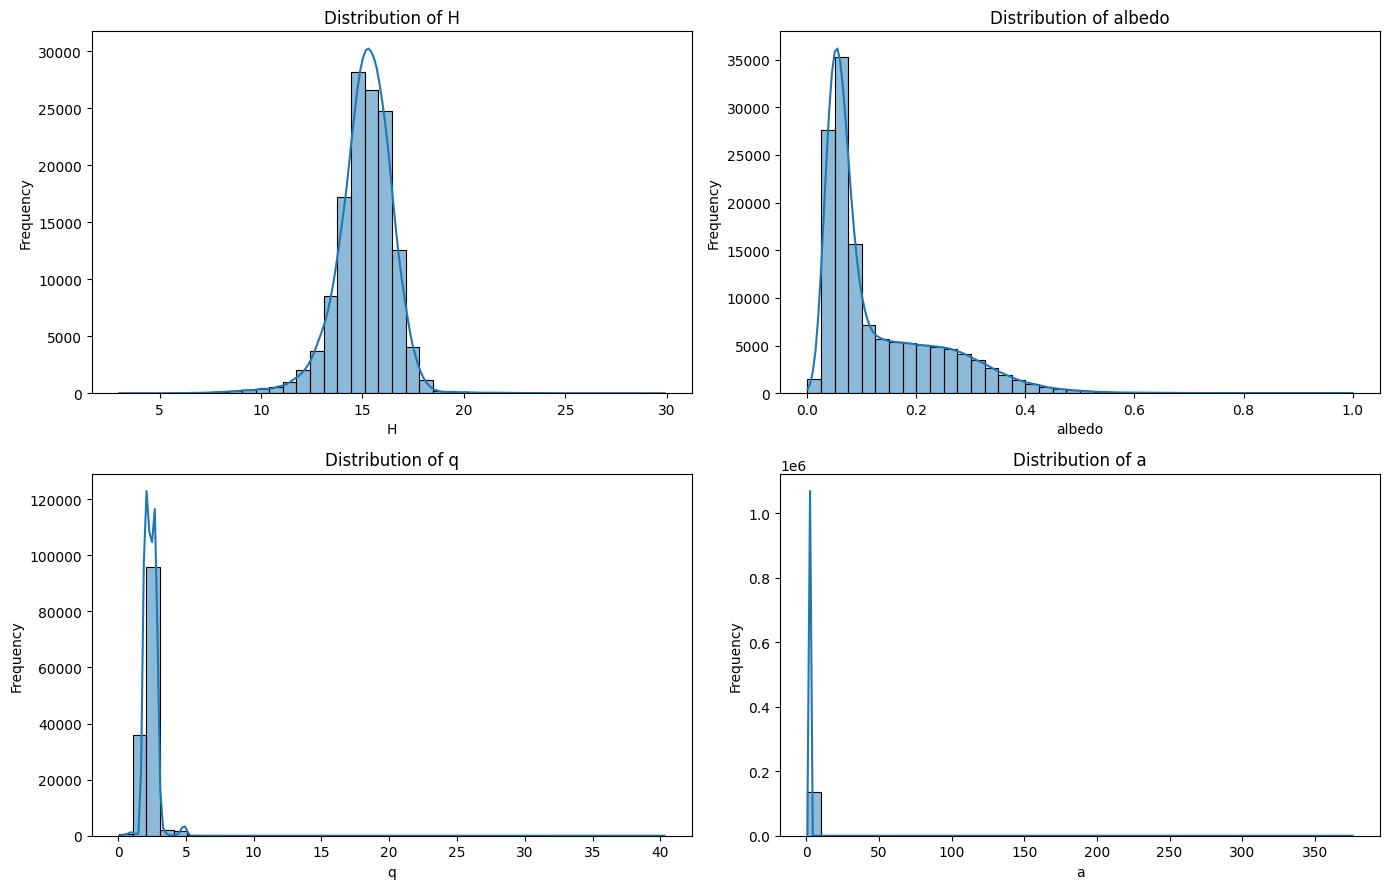

In [49]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

for ax, feature in zip(
    axes.flat,
    important_features
):

    sns.histplot(
        df_asteroid[feature].dropna(),
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

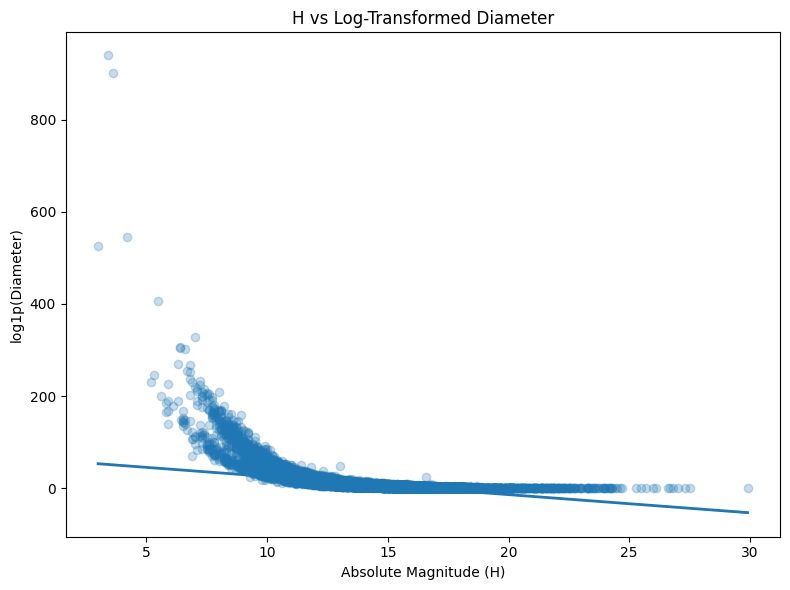

In [53]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_asteroid,
    x='H',
    y='diameter',
    scatter_kws={'alpha': 0.25},
    line_kws={'linewidth': 2}
)

plt.title('H vs Log-Transformed Diameter')
plt.xlabel('Absolute Magnitude (H)')
plt.ylabel('log1p(Diameter)')

plt.tight_layout()
plt.show()

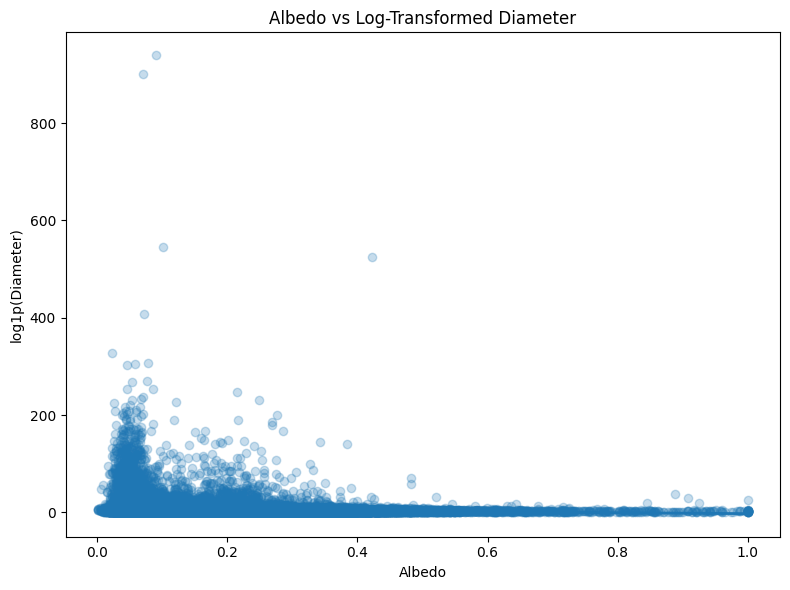

In [55]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_asteroid,
    x='albedo',
    y='diameter',
    scatter_kws={'alpha': 0.25},
    line_kws={'linewidth': 2}
)

plt.title('Albedo vs Log-Transformed Diameter')
plt.xlabel('Albedo')
plt.ylabel('log1p(Diameter)')

plt.tight_layout()
plt.show()

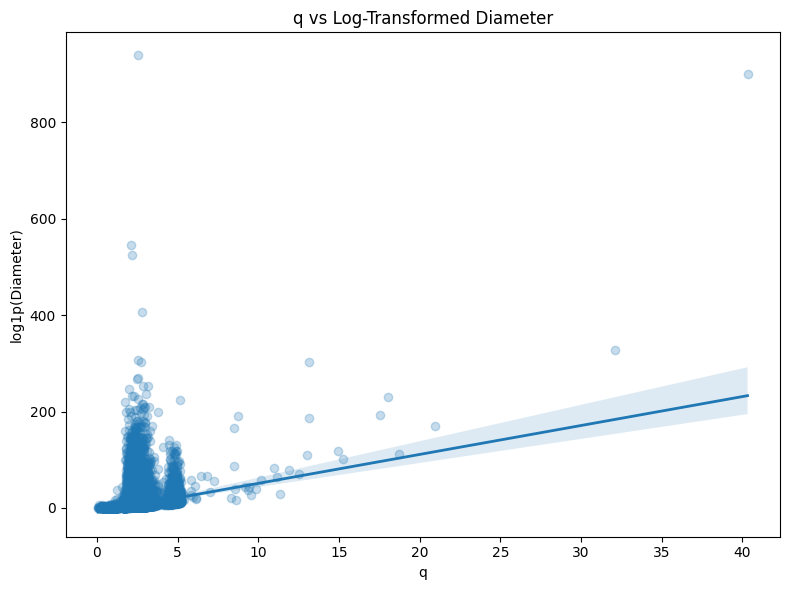

In [56]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_asteroid,
    x='q',
    y='diameter',
    scatter_kws={'alpha': 0.25},
    line_kws={'linewidth': 2}
)

plt.title('q vs Log-Transformed Diameter')
plt.xlabel('q')
plt.ylabel('log1p(Diameter)')

plt.tight_layout()
plt.show()

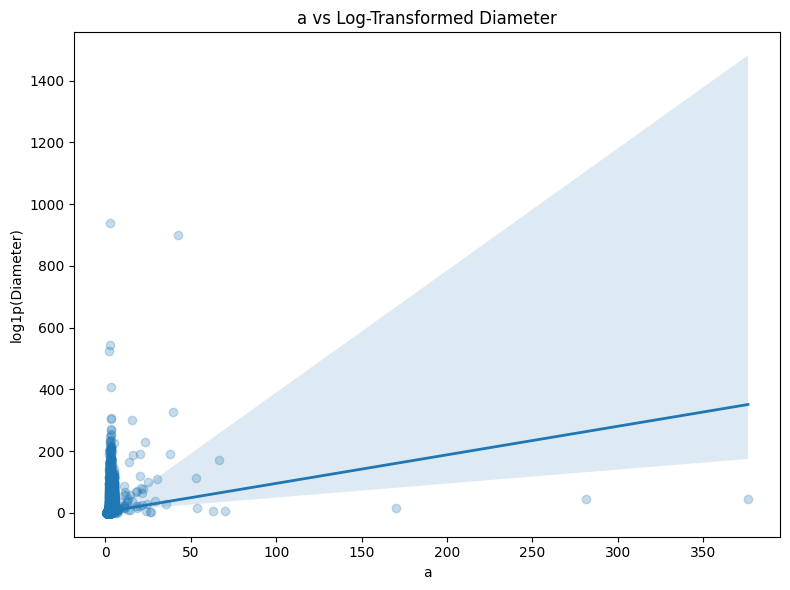

In [57]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df_asteroid,
    x='a',
    y='diameter',
    scatter_kws={'alpha': 0.25},
    line_kws={'linewidth': 2}
)

plt.title('a vs Log-Transformed Diameter')
plt.xlabel('a')
plt.ylabel('log1p(Diameter)')

plt.tight_layout()
plt.show()

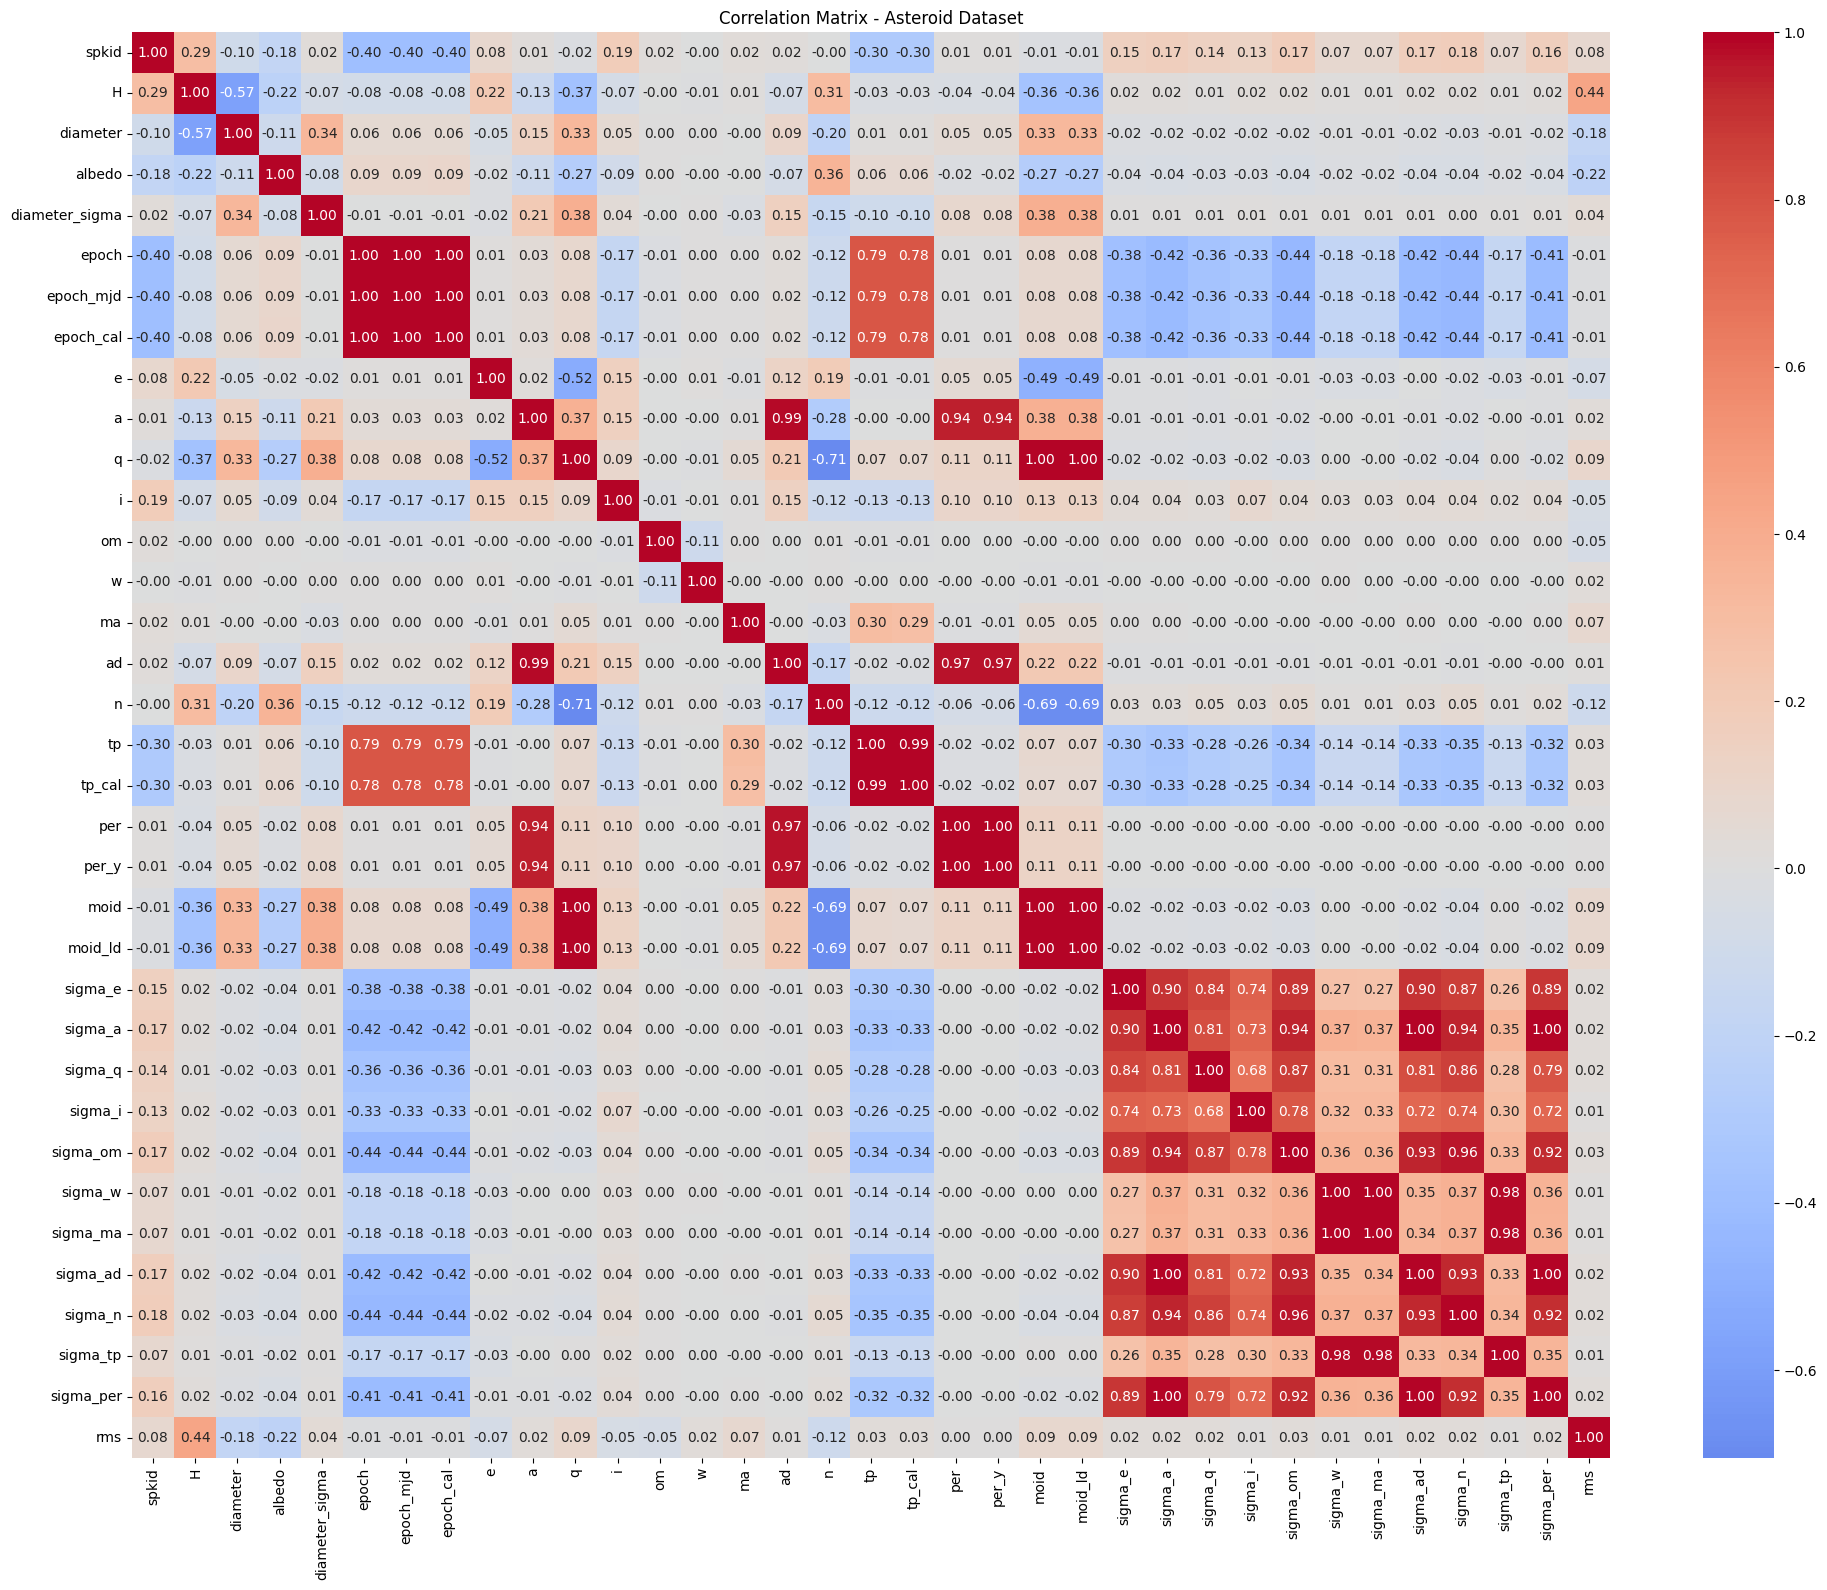

In [58]:
numeric_df = df_asteroid.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix - Asteroid Dataset')
plt.tight_layout()
plt.show()

In [59]:
diameter_corr = (
    numeric_df
    .corr()['diameter']
    .drop('diameter')
    .sort_values()
)

print(diameter_corr)

H                -0.572648
n                -0.199425
rms              -0.182322
albedo           -0.108880
spkid            -0.095362
e                -0.050649
sigma_n          -0.025989
sigma_om         -0.024879
sigma_a          -0.023531
sigma_ad         -0.023295
sigma_per        -0.022720
sigma_e          -0.020864
sigma_q          -0.019447
sigma_i          -0.017378
sigma_w          -0.009857
sigma_ma         -0.009806
sigma_tp         -0.009043
ma               -0.002811
om                0.001530
w                 0.003115
tp                0.013128
tp_cal            0.013350
per               0.050282
per_y             0.050282
i                 0.054963
epoch_mjd         0.058475
epoch             0.058475
epoch_cal         0.058539
ad                0.094735
a                 0.146799
q                 0.329223
moid_ld           0.331983
moid              0.331983
diameter_sigma    0.337145
Name: diameter, dtype: float64


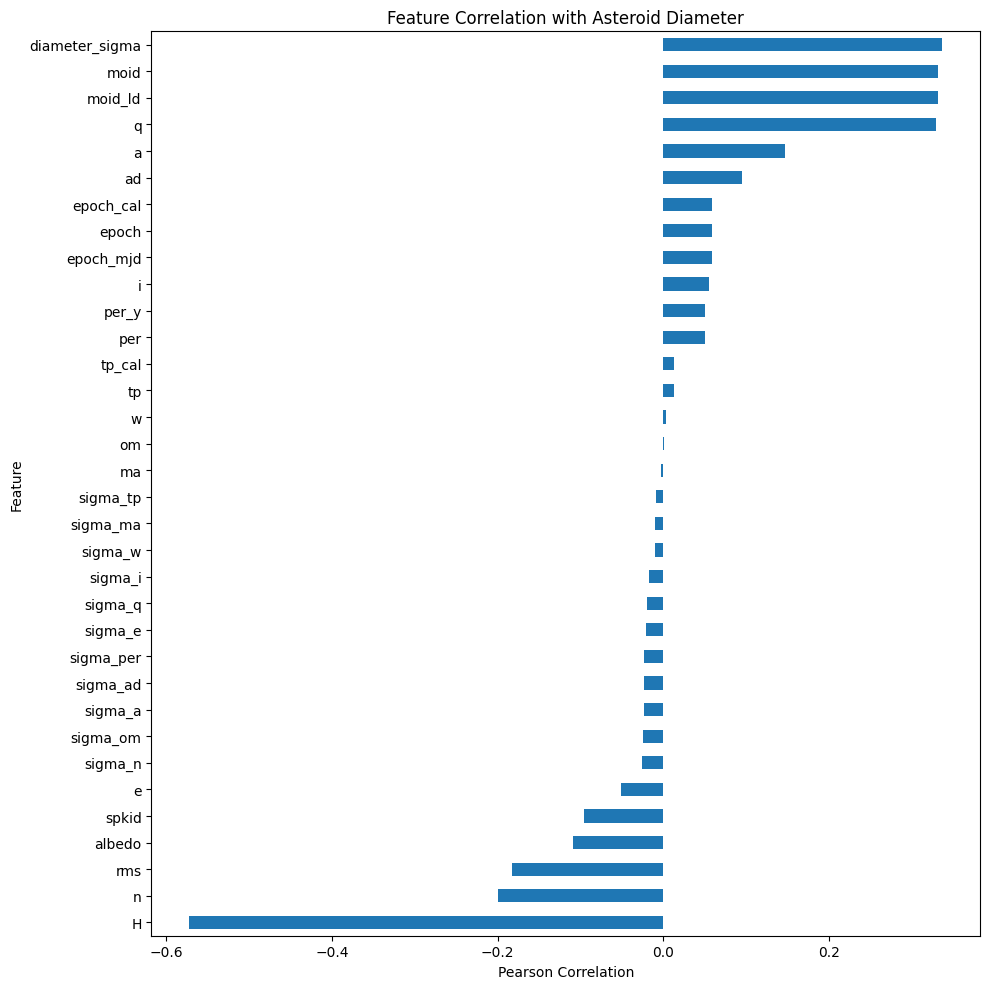

In [60]:
plt.figure(figsize=(10, 10))

diameter_corr.plot(
    kind='barh'
)

plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.title('Feature Correlation with Asteroid Diameter')

plt.tight_layout()
plt.show()

'H' shows the strongest relationship with asteroid diameter, followed by 'q' and 'diameter_sigma', while 'a' and 'albedo' show weaker relationships.


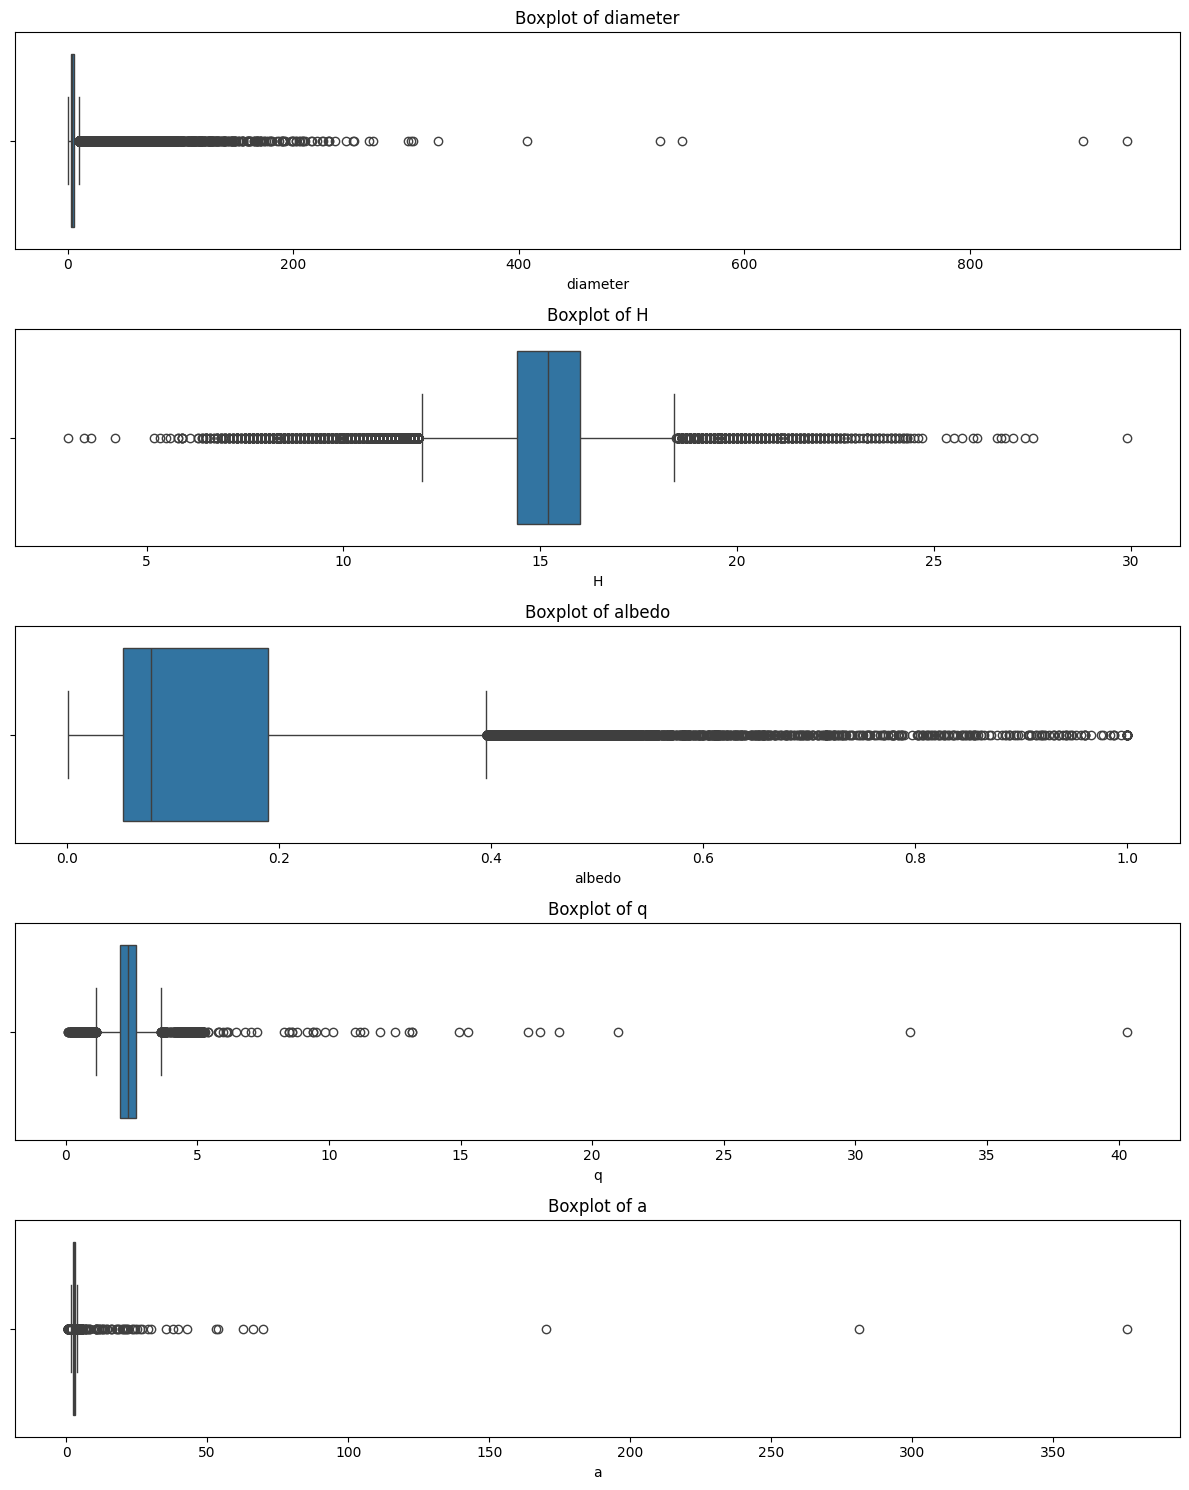

In [61]:
# Outlier analysis
features_for_outliers = [
    'diameter',
    'H',
    'albedo',
    'q',
    'a'
]

features_for_outliers = [
    col for col in features_for_outliers
    if col in df_asteroid.columns
]

fig, axes = plt.subplots(
    len(features_for_outliers),
    1,
    figsize=(12, 3 * len(features_for_outliers))
)

for ax, feature in zip(
    axes,
    features_for_outliers
):

    sns.boxplot(
        x=df_asteroid[feature],
        ax=ax
    )

    ax.set_title(f'Boxplot of {feature}')
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

In [141]:
# Outlier handling using IQR capping

features_for_outliers = ['H', 'albedo', 'q', 'a']

for feature in features_for_outliers:
    Q1 = df_asteroid[feature].quantile(0.25)
    Q3 = df_asteroid[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_asteroid[feature] = df_asteroid[feature].clip(
        lower_bound, upper_bound
    )

print("Outlier capping completed.")

Outlier capping completed.


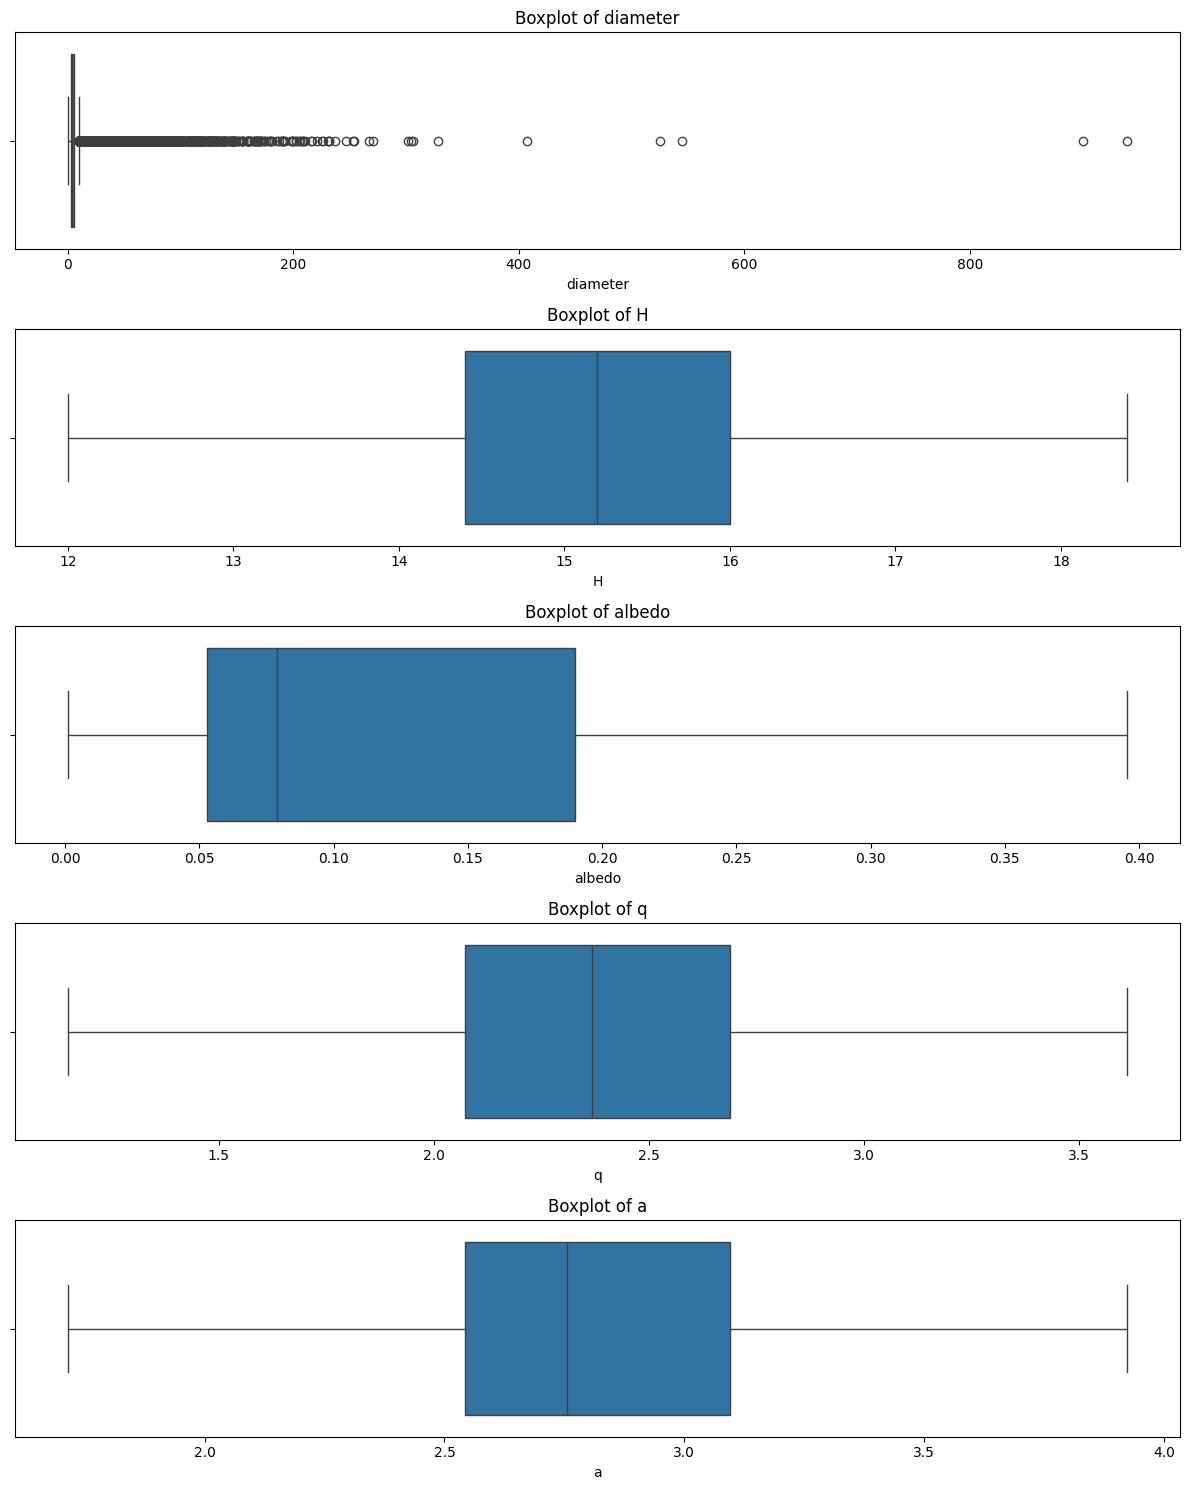

In [142]:
# Outlier analysis
features_for_outliers = [
    'diameter',
    'H',
    'albedo',
    'q',
    'a'
]

features_for_outliers = [
    col for col in features_for_outliers
    if col in df_asteroid.columns
]

fig, axes = plt.subplots(
    len(features_for_outliers),
    1,
    figsize=(12, 3 * len(features_for_outliers))
)

for ax, feature in zip(
    axes,
    features_for_outliers
):

    sns.boxplot(
        x=df_asteroid[feature],
        ax=ax
    )

    ax.set_title(f'Boxplot of {feature}')
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

In [62]:
correlation_threshold = 0.95

feature_corr = (
    df_asteroid
    .select_dtypes(include=np.number)
    .drop(columns=['diameter', 'log_diameter'], errors='ignore')
    .corr()
)

high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):

        correlation = feature_corr.iloc[i, j]

        if abs(correlation) >= correlation_threshold:
            high_corr_pairs.append(
                (
                    feature_corr.columns[i],
                    feature_corr.columns[j],
                    correlation
                )
            )

high_corr_pairs

[('epoch', 'epoch_mjd', np.float64(1.0000000000000004)),
 ('epoch', 'epoch_cal', np.float64(0.9998765245888074)),
 ('epoch_mjd', 'epoch_cal', np.float64(0.999876524588823)),
 ('a', 'ad', np.float64(0.985637197283961)),
 ('q', 'moid', np.float64(0.996838748779052)),
 ('q', 'moid_ld', np.float64(0.996838748779044)),
 ('ad', 'per', np.float64(0.9699935783689033)),
 ('ad', 'per_y', np.float64(0.9699935783689052)),
 ('tp', 'tp_cal', np.float64(0.9938305801394448)),
 ('per', 'per_y', np.float64(1.000000000000006)),
 ('moid', 'moid_ld', np.float64(0.9999999999999913)),
 ('sigma_a', 'sigma_ad', np.float64(0.9967023739739512)),
 ('sigma_a', 'sigma_per', np.float64(0.997794630650324)),
 ('sigma_om', 'sigma_n', np.float64(0.9641342388819512)),
 ('sigma_w', 'sigma_ma', np.float64(0.9987203162496041)),
 ('sigma_w', 'sigma_tp', np.float64(0.9810203484640951)),
 ('sigma_ma', 'sigma_tp', np.float64(0.9810406808295685)),
 ('sigma_ad', 'sigma_per', np.float64(0.9958600007337701))]

In [63]:
redundant_features = [
    'epoch_mjd',
    'epoch_cal',
    'ad',
    'tp_cal',
    'per_y'
]

df_asteroid = df_asteroid.drop(
    columns=redundant_features,
    errors='ignore'
)

print("Removed redundant features:")
print(redundant_features)

Removed redundant features:
['epoch_mjd', 'epoch_cal', 'ad', 'tp_cal', 'per_y']


In [64]:
identifier_columns = [
    'id',
    'spkid',
    'full_name',
    'orbit_id',
    'equinox'
]

df_asteroid = df_asteroid.drop(
    columns=identifier_columns,
    errors='ignore'
)

print("Remaining columns:")
print(df_asteroid.columns.tolist())

Remaining columns:
['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'n', 'tp', 'per', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


Orbital characteristics can affect asteroid size through gravitational interactions, and collision , which influence the size.


In [66]:
df_asteroid.head()

,neo,pha,H,diameter,albedo,diameter_sigma,epoch,e,a,q,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,N,N,3.40,939.400,0.0900,0.200,2458600.5,0.076009,2.769165,2.558684,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,N,N,4.20,545.000,0.1010,18.000,2459000.5,0.229972,2.773841,2.135935,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,N,N,5.33,246.596,0.2140,10.594,2459000.5,0.256936,2.668285,1.982706,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,N,N,3.00,525.400,0.4228,0.200,2458600.5,0.088721,2.361418,2.151909,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,N,N,6.90,106.699,0.2740,3.140,2459000.5,0.190913,2.574037,2.082619,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [74]:
df_asteroid['class'].unique()

array(['MBA', 'OMB', 'MCA', 'AMO', 'IMB', 'TJN', 'CEN', 'APO', 'ATE',
       'AST', 'TNO'], dtype=object)

In [67]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136209 entries, 0 to 909489
Data columns (total 32 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   neo             136209 non-null  object 
 1   pha             136209 non-null  object 
 2   H               132045 non-null  float64
 3   diameter        136209 non-null  float64
 4   albedo          135100 non-null  float64
 5   diameter_sigma  136081 non-null  float64
 6   epoch           136209 non-null  float64
 7   e               136209 non-null  float64
 8   a               136209 non-null  float64
 9   q               136209 non-null  float64
 10  i               136209 non-null  float64
 11  om              136209 non-null  float64
 12  w               136209 non-null  float64
 13  ma              136209 non-null  float64
 14  n               136209 non-null  float64
 15  tp              136209 non-null  float64
 16  per             136209 non-null  float64
 17  moid           

In [79]:

neo_encoder = LabelEncoder()
pha_encoder = LabelEncoder()

df_asteroid['neo_encoded'] = neo_encoder.fit_transform(df_asteroid['neo'])
df_asteroid['pha_encoded'] = pha_encoder.fit_transform(df_asteroid['pha'])

In [76]:

# One-hot encode class
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

class_encoded = encoder.fit_transform(df_asteroid[['class']])

# Convert to DataFrame
class_encoded_df = pd.DataFrame(
    class_encoded,
    columns=encoder.get_feature_names_out(['class']),
    index=df_asteroid.index
)

# Add encoded columns
df_asteroid = pd.concat([df_asteroid, class_encoded_df], axis=1)

In [83]:
df_asteroid.head()

,H,diameter,albedo,diameter_sigma,epoch,e,a,q,i,om,...,class_APO,class_AST,class_ATE,class_CEN,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,3.40,939.400,0.0900,0.200,2458600.5,0.076009,2.769165,2.558684,10.594067,80.305531,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,4.20,545.000,0.1010,18.000,2459000.5,0.229972,2.773841,2.135935,34.832932,173.024741,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,5.33,246.596,0.2140,10.594,2459000.5,0.256936,2.668285,1.982706,12.991043,169.851482,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3.00,525.400,0.4228,0.200,2458600.5,0.088721,2.361418,2.151909,7.141771,103.810804,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,6.90,106.699,0.2740,3.140,2459000.5,0.190913,2.574037,2.082619,5.367427,141.571026,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [82]:
df_asteroid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136209 entries, 0 to 909489
Data columns (total 53 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   H               132045 non-null  float64
 1   diameter        136209 non-null  float64
 2   albedo          135100 non-null  float64
 3   diameter_sigma  136081 non-null  float64
 4   epoch           136209 non-null  float64
 5   e               136209 non-null  float64
 6   a               136209 non-null  float64
 7   q               136209 non-null  float64
 8   i               136209 non-null  float64
 9   om              136209 non-null  float64
 10  w               136209 non-null  float64
 11  ma              136209 non-null  float64
 12  n               136209 non-null  float64
 13  tp              136209 non-null  float64
 14  per             136209 non-null  float64
 15  moid            136209 non-null  float64
 16  moid_ld         136209 non-null  float64
 17  sigma_e        

In [81]:
# Add encoded class columns
df_asteroid = pd.concat([df_asteroid, class_encoded_df], axis=1)


# Label Encode NEO and PHA
neo_encoder = LabelEncoder()
pha_encoder = LabelEncoder()

df_asteroid['neo_encoded'] = neo_encoder.fit_transform(df_asteroid['neo'])
df_asteroid['pha_encoded'] = pha_encoder.fit_transform(df_asteroid['pha'])


# Drop original categorical columns
df_asteroid.drop(columns=['class', 'neo', 'pha'], inplace=True)

# Check the result
print(df_asteroid[['neo_encoded', 'pha_encoded']].head())

   neo_encoded  pha_encoded
0            0            0
1            0            0
2            0            0
3            0            0
4            0            0


In [123]:

# Select features and target
features = ['H', 'q', 'a', 'albedo']
X = df_asteroid[features]
y = df_asteroid['diameter']

# Split before imputation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fill missing values using training medians
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [129]:

# Calculate mutual information
X_mi = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

mi_scores = mutual_info_regression(
    X_mi, y, random_state=42
)

# Create MI dataframe
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information': mi_scores
})

# Sort by MI
mi_df = mi_df.sort_values(
    'Mutual Information',
    ascending=False
)

mi_df

,Feature,Mutual Information
3,albedo,1.447642
0,H,0.729869
1,q,0.252801
2,a,0.246296


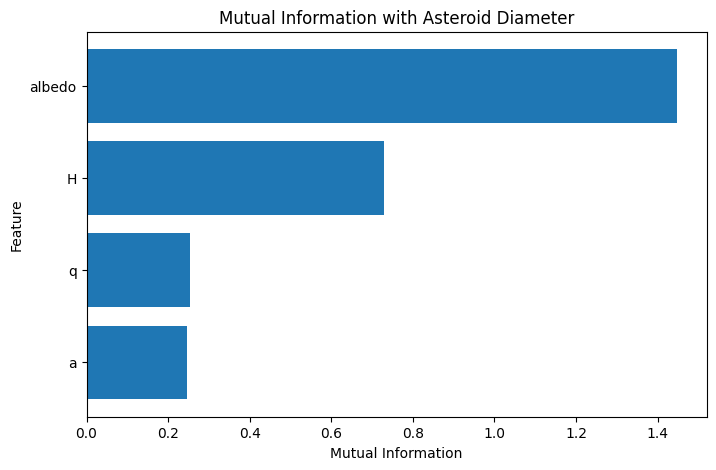

In [130]:

plt.figure(figsize=(8, 5))

plt.barh(
    mi_df['Feature'],
    mi_df['Mutual Information']
)

plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.title('Mutual Information with Asteroid Diameter')

plt.gca().invert_yaxis()
plt.show()

Scaling brings features to a comparable range, improving DNN training stability and convergence.

Removed epoch_mjd, epoch_cal, ad, tp_cal, per_y, id, spkid, full_name, orbit_id, equinox, and diameter_sigma because they were redundant, irrelevant, or potentially caused target leakage.


Highly correlated features give the model similar or duplicate information.

#Task3

In [96]:
# Model building

def build_model(neurons, dropout, learning_rate):

    model = keras.Sequential()

    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # First hidden layer
    model.add(layers.Dense(neurons, activation='relu'))

    # Dropout for regularization
    model.add(layers.Dropout(dropout))

    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(16, activation='relu'))

    # Output layer for regression
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='mse',
        metrics=['mae']
    )

    return model

In [125]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_final.shape)
print("Validation data:", X_val.shape)

Training data: (87173, 4)
Validation data: (21794, 4)


In [103]:
#  hyperparameter values for tuning

dropout_list = [0.1, 0.3]
learning_rates = [0.001, 0.0001]

In [126]:
results = []

for dropout in [0.1, 0.3]:
    for lr in [0.001, 0.0001]:

        model = build_model(32, dropout, lr)

        history_temp = model.fit(
            X_train_final,
            y_train_final,
            validation_data=(X_val, y_val),
            epochs=3,
            batch_size=64,
            verbose=0
        )

        results.append({
            'dropout': dropout,
            'learning_rate': lr,
            'val_loss': min(history_temp.history['val_loss'])
        })

results_df = pd.DataFrame(results)

results_df.sort_values('val_loss')

,dropout,learning_rate,val_loss
0,0.1,0.0010,20.244112
2,0.3,0.0010,31.431612
3,0.3,0.0001,75.187141
1,0.1,0.0001,79.568962


In [132]:
# Select the best hyperparameters

best_row = results_df.sort_values('val_loss').iloc[0]

best_dropout = best_row['dropout']
best_lr = best_row['learning_rate']

print("Best dropout:", best_dropout)
print("Best learning rate:", best_lr)
print("Best validation loss:", best_row['val_loss'])

Best dropout: 0.1
Best learning rate: 0.001
Best validation loss: 20.244112014770508


In [133]:
# Train the final model

best_model = build_model(32, best_dropout, best_lr)

history = best_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 28.2470 - mae: 1.4716 - val_loss: 123.4076 - val_mae: 1.0373
Epoch 2/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 10.0781 - mae: 0.8821 - val_loss: 29.2569 - val_mae: 0.7552
Epoch 3/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.8580 - mae: 0.8213 - val_loss: 21.7300 - val_mae: 0.6723
Epoch 4/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6.2729 - mae: 0.7849 - val_loss: 32.8230 - val_mae: 0.7302
Epoch 5/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6.5100 - mae: 0.7969 - val_loss: 19.9213 - val_mae: 0.6442
Epoch 6/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 5.0334 - mae: 0.7519 - val_loss: 21.0138 - val_mae: 0.6394
Epoch 7/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.9454 - mae: 0.7626 - val_loss: 25.8234 - val_mae: 0.6309
Epoch 8/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.9272 - mae: 0.7382 - val_loss: 20.3268 - val_mae: 0.6074
Epoch 9/10
1363/1363 ━━━━━━━

In [134]:
# Build the final model
best_model = build_model(32, best_dropout, best_lr)

# Train the model
history = best_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 24.6088 - mae: 1.5749 - val_loss: 65.5882 - val_mae: 1.0071
Epoch 2/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 9.6793 - mae: 0.9184 - val_loss: 30.4237 - val_mae: 0.7273
Epoch 3/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 7.0411 - mae: 0.7837 - val_loss: 19.6785 - val_mae: 1.1764
Epoch 4/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 6.1521 - mae: 0.7777 - val_loss: 16.7602 - val_mae: 0.6006
Epoch 5/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5.6040 - mae: 0.7428 - val_loss: 17.6552 - val_mae: 0.6137
Epoch 6/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.6764 - mae: 0.7184 - val_loss: 10.4216 - val_mae: 0.5972
Epoch 7/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.8209 - mae: 0.7073 - val_loss: 25.1882 - val_mae: 0.6238
Epoch 8/10
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.1818 - mae: 0.6956 - val_loss: 20.7843 - val_mae: 0.6153
Epoch 9/10
1363/1363 ━━━━━━━━━━

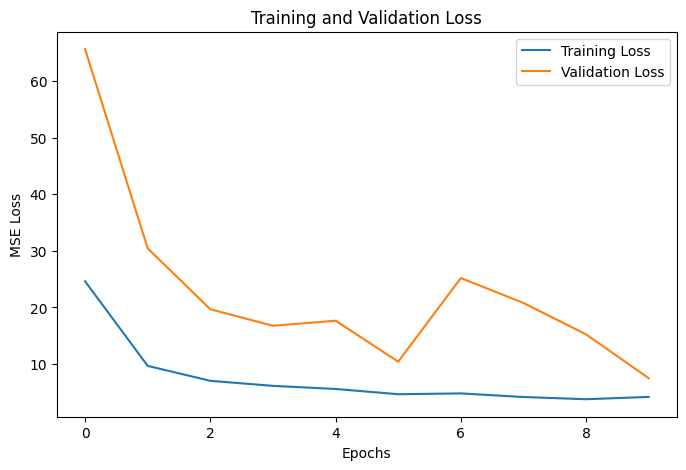

In [135]:

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

Target value (diameter) is a continuous numerical value. A linear activation is used in the output layer because it allows the model to produce any real-valued output without limiting  to a specific range.

Learning rate had the greatest impact on performance. Changing it from 0.001 to 0.0001 increased validation loss substantially

#Task 4

In [136]:
y_pred = best_model.predict(X_test_scaled).flatten()

# regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Model Performance")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

852/852 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Regression Model Performance
MAE  : 0.6243827296441352
MSE  : 11.139846649707435
RMSE : 3.337640880877905
R²   : 0.8895733158197233


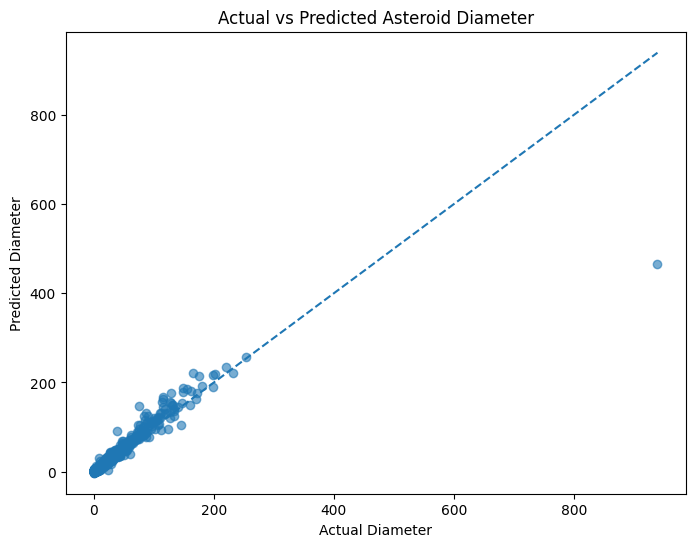

In [137]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Diameter')
plt.ylabel('Predicted Diameter')
plt.title('Actual vs Predicted Asteroid Diameter')
plt.show()

852/852 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


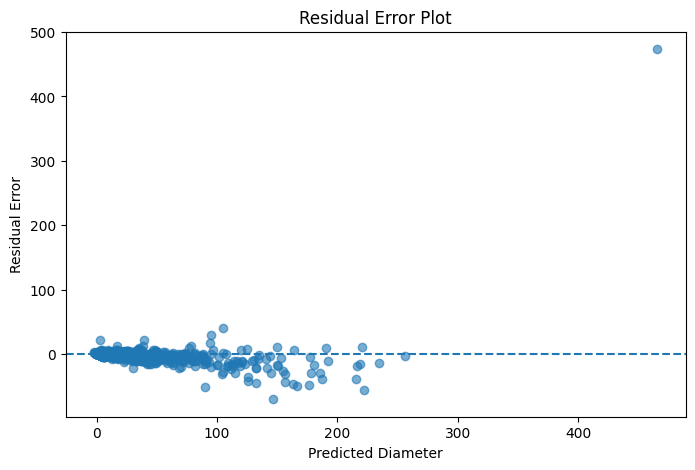

In [139]:
#  predictions and residual errors
y_pred = best_model.predict(X_test_scaled).flatten()
residuals = y_test - y_pred

# Plot residual errors
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Diameter')
plt.ylabel('Residual Error')
plt.title('Residual Error Plot')
plt.show()



In [140]:
# Find 10 largest prediction errors
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': residuals.values,
    'Absolute_Error': np.abs(residuals.values)
})

top_10_errors = error_df.sort_values(
    'Absolute_Error',
    ascending=False
).head(10)

top_10_errors

,Actual,Predicted,Residual,Absolute_Error
12322,939.400,466.076233,473.323767,473.323767
9531,76.000,146.427170,-70.427170,70.427170
18277,166.000,222.059265,-56.059265,56.059265
23798,39.100,90.232613,-51.132613,51.132613
17139,116.044,166.588928,-50.544928,50.544928
4163,128.578,176.228195,-47.650195,47.650195
640,115.974,162.984604,-47.010604,47.010604
4540,86.500,132.347260,-45.847260,45.847260
268,113.000,156.587463,-43.587463,43.587463
5440,83.040,125.897659,-42.857659,42.857659


R² best represents the overall model performance because it indicates how much variation in asteroid diameter is explained by the model. The obtained R² of 0.89 indicates that the model explains approximately 89% of the variance in asteroid diameter

The residuals are mostly centered around zero, but their spread increases for larger predicted diameters. A major positive outlier is also present, indicating significant underprediction for one large asteroid.